# Data Exploration

My goal in this notebook is to explore the dataset.  
This notebook is heavily inspired by the data analysis course.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data/raw"

champs_df = pd.read_csv(DATA_DIR / "champs.csv")
matches_df = pd.read_csv(DATA_DIR / "matches.csv")
participants_df = pd.read_csv(DATA_DIR / "participants.csv")
stats1_df = pd.read_csv(DATA_DIR / "stats1.csv")
stats2_df = pd.read_csv(DATA_DIR / "stats2.csv")
teambans_df = pd.read_csv(DATA_DIR / "teambans.csv")
teamstats_df = pd.read_csv(DATA_DIR / "teamstats.csv")

# NOTE: I merged stats aferwards because they are the same data but split into two files.
stats2_df = stats2_df[stats1_df.columns]
stats_df = pd.concat([stats1_df, stats2_df], axis=0, ignore_index=True)


all_dfs = {
    "champs": champs_df,
    "matches": matches_df,
    "participants": participants_df,
    "stats": stats_df,
    "teambans": teambans_df,
    "teamstats": teamstats_df,
}

/tmp/ipykernel_133720/134812854.py:8: DtypeWarning: Columns (0: wardsbought) have mixed types. Specify dtype option on import or set low_memory=False.
  stats2_df = pd.read_csv(DATA_DIR / "stats2.csv")


In [4]:
for name, df in all_dfs.items():
    print(f"\n{name}:")
    print(f"shape: {df.shape}")
    print(f"dtypes values:\n{df.dtypes.value_counts()}")
    print(f"memory_usage: {df.memory_usage(deep=True).sum() / 1024**2} MB")


champs:
shape: (138, 2)
dtypes values:
str      1
int64    1
Name: count, dtype: int64
memory_usage: 0.00843048095703125 MB

matches:
shape: (184069, 8)
dtypes values:
int64    6
str      2
Name: count, dtype: int64
memory_usage: 28.42035484313965 MB

participants:
shape: (1834520, 8)
dtypes values:
int64    6
str      2
Name: count, dtype: int64
memory_usage: 272.57017517089844 MB

stats:
shape: (1834517, 56)
dtypes values:
int64     55
object     1
Name: count, dtype: int64
memory_usage: 838.8466444015503 MB

teambans:
shape: (1099185, 4)
dtypes values:
int64    4
Name: count, dtype: int64
memory_usage: 33.54458999633789 MB

teamstats:
shape: (368138, 13)
dtypes values:
int64    13
Name: count, dtype: int64
memory_usage: 36.51283645629883 MB


## 2. Schema Overview

In [5]:
def sample_values(series, n=3):
    vals = series.dropna().astype(str).unique()[:n]
    return ", ".join(vals) if len(vals) else "(all missing)"

schema_rows = []

for table_name, df in all_dfs.items():
    for col in df.columns:
        s = df[col]
        schema_rows.append({
            "table": table_name,
            "column": col,
            "dtype": str(s.dtype),
            "non_null": int(s.notna().sum()),
            "null_pct": round(s.isna().mean() * 100, 2),
            "n_unique": int(s.nunique(dropna=True)),
            "sample_values": sample_values(s, n=3),
        })

schema_overview = pd.DataFrame(schema_rows).sort_values(["table", "column"]).reset_index(drop=True)
pd.set_option("display.max_rows", None)
schema_overview

,table,column,dtype,non_null,null_pct,n_unique,sample_values
0,champs,id,int64,138,0.0,138,"24, 37, 18"
1,champs,name,str,138,0.0,138,"Jax, Sona, Tristana"
2,matches,creation,int64,184069,0.0,184042,"1495068946860, 1495066760778, 1495053375889"
3,matches,duration,int64,184069,0.0,3057,"1909, 1693, 1482"
4,matches,gameid,int64,184069,0.0,184069,"3187427022, 3187425281, 3187269801"
5,matches,id,int64,184069,0.0,184069,"10, 11, 12"
6,matches,platformid,str,184069,0.0,4,"EUW1, NA1, EUN1"
7,matches,queueid,int64,184069,0.0,7,"420, 440, 410"
8,matches,seasonid,int64,184069,0.0,6,"8, 7, 6"
9,matches,version,str,184069,0.0,152,"7.10.187.9675, 7.9.186.8155, 7.9.186.1051"


## 3. Missing Values

In [6]:
# Null perdentage from previous table is 0 for all Columns no missing values

## 4. Target Distribution

In [8]:
counts = stats_df["win"].value_counts()
perc = stats_df["win"].value_counts(normalize=True) * 100

dist = pd.DataFrame({"count": counts, "percentage": perc})

dist

,count,percentage
win,,
0,917259,50.000027
1,917258,49.999973


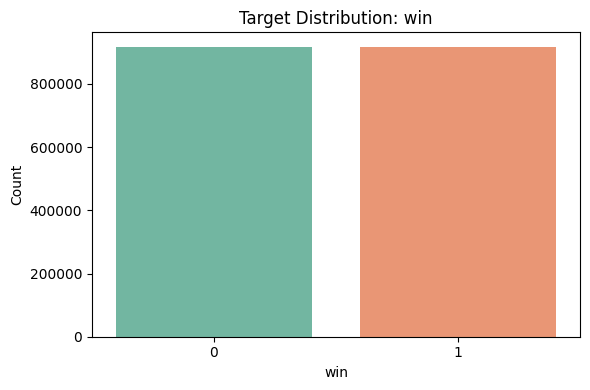

In [13]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str), palette="Set2")
ax.set_title("Target Distribution: win")
ax.set_xlabel("win")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 5. Univariate Analysis

## 6. Bivariate Analysis

## 7. Correlation Analysis

## 8. Temporal Analysis

## 9. Champion Analysis

## 10. Findings